# Per-CpG Meta-Analysis
## Step 4: Combining evidence across all 9 cohorts

**Why meta-analysis?**
Each cohort has n=11–21 — too small to detect subtle methylation differences on its own. Meta-analysis formally combines the statistical evidence across all 9 datasets. A CpG that shows a consistent trend across multiple cohorts — even if never significant in any single one — can reach significance when the evidence is pooled.

**Method: Mann-Whitney U + Stouffer's Z**

For each CpG in each dataset:
1. **Mann-Whitney U test** — non-parametric rank test comparing beta values between case and control. Chosen because: no normality assumption, robust to outliers, appropriate for small n
2. **Delta beta** — mean(case) − mean(control). The effect size: positive = hypermethylated in cases

Then across datasets:
3. **Stouffer's Z** — combines signed Z-scores weighted by √n. The sign comes from delta beta direction, so CpGs that flip direction across cohorts cancel out (correctly penalised)
4. **Benjamini-Hochberg FDR** — controls false discovery rate across all CpGs tested

**Key output:** A ranked list of CpGs with consistent methylation differences across early-life exposure cohorts, regardless of exposure type.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import mannwhitneyu, norm
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## Cell 2 — Configuration

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR  = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR   = PROJECT_ROOT / 'results' / 'tables'

for d in [FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATASETS = [
    'wildfire',
    'stress',
    'obesity_hippocampus',
    'obesity_hypothalamus',
    'obesity_prefrontalcortex',
    'cfdna_GD45',
    'cfdna_GD90',
    'cfdna_GD120',
    'cfdna_GD150',
]
REGIONS = ['cpgi', 'genebody']

# Minimum number of datasets a CpG must appear in to be included
MIN_DATASETS = 3

print(f'Datasets : {len(DATASETS)}')
print(f'Regions  : {REGIONS}')
print(f'MIN_DATASETS (CpG must appear in ≥ this many cohorts): {MIN_DATASETS}')

Datasets : 9
Regions  : ['cpgi', 'genebody']
MIN_DATASETS (CpG must appear in ≥ this many cohorts): 3


## Cell 3 — Load All Data

We load the beta matrix and labels for every dataset, then store them in dictionaries for easy access in the analysis loop.

In [3]:
beta  = {}   # beta[dataset][region]  = DataFrame(samples × CpGs)
labels = {}  # labels[dataset]         = Series(sample → 0/1)

for ds in DATASETS:
    label_path = DATA_DIR / f'{ds}_labels.csv'
    if not label_path.exists():
        print(f'[SKIP] No labels file for {ds}')
        continue

    lab = pd.read_csv(label_path, index_col='sample_id')
    lab.index = lab.index.astype(str)
    labels[ds] = lab['label']

    beta[ds] = {}
    for region in REGIONS:
        path = DATA_DIR / f'{ds}_{region}_methylation.csv'
        if path.exists():
            df = pd.read_csv(path, index_col=0).T   # samples × CpGs
            df.index = df.index.astype(str)
            beta[ds][region] = df
        else:
            print(f'[MISSING] {ds}_{region}_methylation.csv')

print('Loaded datasets:')
for ds in beta:
    for region in beta[ds]:
        b = beta[ds][region]
        n = len(labels[ds])
        print(f'  {ds:35s} {region:10s}: {b.shape[0]} samples × {b.shape[1]} CpGs')

Loaded datasets:
  wildfire                            cpgi      : 21 samples × 42 CpGs
  wildfire                            genebody  : 21 samples × 245 CpGs
  stress                              cpgi      : 76 samples × 42 CpGs
  stress                              genebody  : 76 samples × 241 CpGs
  obesity_hippocampus                 cpgi      : 13 samples × 42 CpGs
  obesity_hippocampus                 genebody  : 13 samples × 241 CpGs
  obesity_hypothalamus                cpgi      : 13 samples × 42 CpGs
  obesity_hypothalamus                genebody  : 13 samples × 241 CpGs
  obesity_prefrontalcortex            cpgi      : 13 samples × 42 CpGs
  obesity_prefrontalcortex            genebody  : 13 samples × 241 CpGs
  cfdna_GD45                          cpgi      : 11 samples × 36 CpGs
  cfdna_GD45                          genebody  : 11 samples × 228 CpGs
  cfdna_GD90                          cpgi      : 11 samples × 42 CpGs
  cfdna_GD90                          genebody  : 11 s

## Cell 4 — Per-CpG Mann-Whitney Test per Dataset

For each CpG in each dataset we compute:
- **U statistic and p-value** from Mann-Whitney U test (two-sided)
- **Delta beta** = mean(case betas) − mean(control betas)
  - Positive → CpG is more methylated in exposed animals
  - Negative → CpG is less methylated in exposed animals
- **Signed Z-score** = direction × |Φ⁻¹(p/2)|
  - Converts p-value back to a Z-score but preserves the direction of effect
  - This is what Stouffer's method will combine across cohorts

**What to remember:** `norm.ppf(p/2)` is the inverse normal CDF — it converts a probability into a Z-score. We use `abs()` then multiply by `sign(delta_beta)` to get a signed Z.

In [4]:
per_dataset_results = {}   # per_dataset_results[region][dataset][cpg] → {p, delta_beta, Z}

for region in REGIONS:
    per_dataset_results[region] = {}

    for ds in DATASETS:
        if ds not in beta or region not in beta[ds]:
            continue

        X = beta[ds][region]
        y = labels[ds].reindex(X.index).dropna()
        X = X.reindex(y.index)

        ctrl_idx = y[y == 0].index
        case_idx = y[y == 1].index

        results = {}
        for cpg in X.columns:
            ctrl_vals = X.loc[ctrl_idx, cpg].dropna()
            case_vals = X.loc[case_idx, cpg].dropna()

            if len(ctrl_vals) < 3 or len(case_vals) < 3:
                continue

            stat, pval = mannwhitneyu(ctrl_vals, case_vals, alternative='two-sided')
            delta_beta  = case_vals.mean() - ctrl_vals.mean()

            # Convert p-value to signed Z-score
            # norm.ppf(pval/2) gives a negative Z; abs then re-sign by delta direction
            z = abs(norm.ppf(pval / 2)) * np.sign(delta_beta)
            # Clip p-value away from 0 to avoid infinite Z
            pval = max(pval, 1e-15)

            results[cpg] = {
                'p_value'    : pval,
                'delta_beta' : delta_beta,
                'Z'          : z,
                'n_ctrl'     : len(ctrl_vals),
                'n_case'     : len(case_vals),
            }

        per_dataset_results[region][ds] = results
        print(f'  {ds:35s} {region}: {len(results)} CpGs tested')

print('\nPer-dataset testing complete.')

  wildfire                            cpgi: 42 CpGs tested
  stress                              cpgi: 42 CpGs tested
  obesity_hippocampus                 cpgi: 42 CpGs tested
  obesity_hypothalamus                cpgi: 42 CpGs tested
  obesity_prefrontalcortex            cpgi: 42 CpGs tested
  cfdna_GD45                          cpgi: 36 CpGs tested
  cfdna_GD90                          cpgi: 42 CpGs tested
  cfdna_GD120                         cpgi: 42 CpGs tested
  cfdna_GD150                         cpgi: 42 CpGs tested
  wildfire                            genebody: 245 CpGs tested
  stress                              genebody: 241 CpGs tested
  obesity_hippocampus                 genebody: 241 CpGs tested
  obesity_hypothalamus                genebody: 241 CpGs tested
  obesity_prefrontalcortex            genebody: 241 CpGs tested
  cfdna_GD45                          genebody: 228 CpGs tested
  cfdna_GD90                          genebody: 219 CpGs tested
  cfdna_GD120        

## Cell 5 — Stouffer's Meta-Analysis

**How Stouffer's works:**

For each CpG, across all datasets where it was tested:

Combined Z = Σ(wᵢ × Zᵢ) / √Σ(wᵢ²)

Where wᵢ = √nᵢ (square root of total sample size in dataset i). Larger datasets contribute more. The combined Z is then converted back to a p-value using the normal distribution.

**Consistency score:** What fraction of datasets show the same direction of effect (sign of delta beta)? A CpG with combined p=0.01 but consistency=0.5 (half the cohorts go opposite directions) is less trustworthy than one with consistency=1.0.

In [5]:
meta_results = {}

for region in REGIONS:
    records = []
    all_cpgs = set()
    for ds in per_dataset_results[region]:
        all_cpgs.update(per_dataset_results[region][ds].keys())

    print(f'{region}: {len(all_cpgs)} unique CpGs across all datasets')

    for cpg in all_cpgs:
        Zs  = []
        ws  = []
        deltas    = []
        n_tested  = 0
        p_vals_ds = {}

        for ds in DATASETS:
            if ds not in per_dataset_results[region]:
                continue
            if cpg not in per_dataset_results[region][ds]:
                continue

            r  = per_dataset_results[region][ds][cpg]
            n  = r['n_ctrl'] + r['n_case']
            w  = np.sqrt(n)

            Zs.append(r['Z'])
            ws.append(w)
            deltas.append(r['delta_beta'])
            p_vals_ds[ds] = r['p_value']
            n_tested += 1

        if n_tested < MIN_DATASETS:
            continue

        # Stouffer's combined Z
        Zs = np.array(Zs)
        ws = np.array(ws)
        combined_Z = np.dot(ws, Zs) / np.sqrt(np.sum(ws ** 2))
        combined_p = 2 * norm.sf(abs(combined_Z))

        # Weighted mean delta beta
        weighted_delta = np.average(deltas, weights=ws)

        # Consistency: fraction of datasets with same sign as weighted_delta
        signs = np.sign(deltas)
        consensus_sign = np.sign(weighted_delta)
        consistency = np.mean(signs == consensus_sign)

        records.append({
            'cpg'            : cpg,
            'combined_Z'     : round(combined_Z, 4),
            'combined_p'     : combined_p,
            'weighted_delta_beta': round(weighted_delta, 4),
            'n_datasets'     : n_tested,
            'consistency'    : round(consistency, 2),
            **{f'delta_{ds}': round(per_dataset_results[region].get(ds, {}).get(cpg, {}).get('delta_beta', np.nan), 4)
               for ds in DATASETS},
            **{f'p_{ds}': round(per_dataset_results[region].get(ds, {}).get(cpg, {}).get('p_value', np.nan), 4)
               for ds in DATASETS},
        })

    df = pd.DataFrame(records)

    # FDR correction (Benjamini-Hochberg)
    # Controls the expected proportion of false discoveries among significant results
    reject, p_fdr, _, _ = multipletests(df['combined_p'], method='fdr_bh')
    df['p_fdr']      = p_fdr
    df['significant'] = reject   # FDR < 0.05

    df = df.sort_values('combined_p')
    meta_results[region] = df

    n_sig = df['significant'].sum()
    print(f'  Significant CpGs (FDR<0.05): {n_sig} / {len(df)}')
    print(f'  Top CpG: {df.iloc[0]["cpg"]}  Z={df.iloc[0]["combined_Z"]:.3f}  p={df.iloc[0]["combined_p"]:.4f}  delta={df.iloc[0]["weighted_delta_beta"]:.4f}\n')

    df.to_csv(TABLES_DIR / f'meta_analysis_{region}.csv', index=False)
    print(f'  Saved: meta_analysis_{region}.csv')

cpgi: 42 unique CpGs across all datasets
  Significant CpGs (FDR<0.05): 0 / 42
  Top CpG: 2433347  Z=-1.893  p=0.0583  delta=-0.0141

  Saved: meta_analysis_cpgi.csv
genebody: 245 unique CpGs across all datasets
  Significant CpGs (FDR<0.05): 0 / 241
  Top CpG: 2434199  Z=2.498  p=0.0125  delta=0.0571

  Saved: meta_analysis_genebody.csv


## Cell 6 — Volcano Plot

A volcano plot shows effect size (x-axis: weighted delta beta) vs statistical significance (y-axis: −log₁₀ p-value). CpGs in the top-right are hypermethylated in cases AND statistically supported. Top-left are hypomethylated in cases.

Points are coloured by consistency score — how often all cohorts agree on the direction.

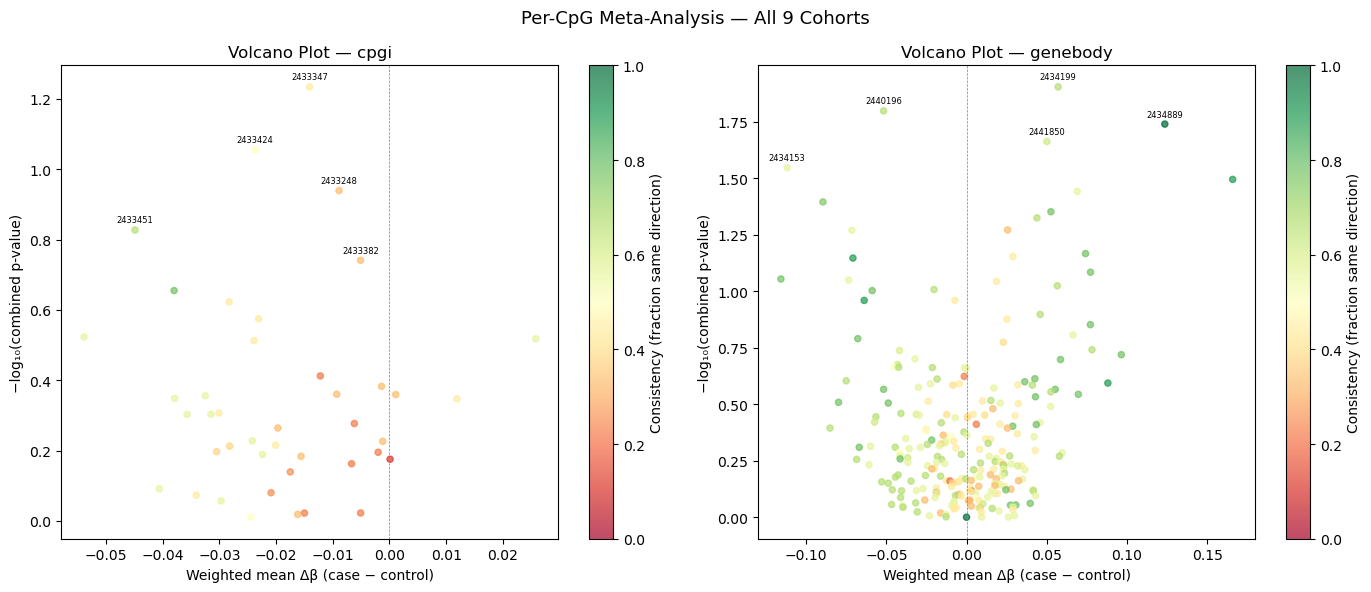

Saved: meta_volcano.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for col_idx, region in enumerate(REGIONS):
    df  = meta_results[region]
    ax  = axes[col_idx]

    y_vals = -np.log10(df['combined_p'].clip(lower=1e-15))

    sc = ax.scatter(
        df['weighted_delta_beta'],
        y_vals,
        c=df['consistency'],
        cmap='RdYlGn',
        vmin=0, vmax=1,
        alpha=0.7, s=20
    )
    plt.colorbar(sc, ax=ax, label='Consistency (fraction same direction)')

    # FDR threshold line
    fdr_thresh = df.loc[df['significant'], 'combined_p'].max() if df['significant'].any() else None
    if fdr_thresh:
        ax.axhline(-np.log10(fdr_thresh), color='red', ls='--', lw=1,
                   label=f'FDR=0.05 threshold')
        ax.legend(fontsize=8)

    # Label top 5 CpGs
    for _, row in df.head(5).iterrows():
        ax.annotate(
            row['cpg'],
            (row['weighted_delta_beta'], -np.log10(row['combined_p'])),
            fontsize=6, ha='center', va='bottom',
            xytext=(0, 4), textcoords='offset points'
        )

    ax.axvline(0, color='grey', lw=0.5, ls='--')
    ax.set_xlabel('Weighted mean Δβ (case − control)')
    ax.set_ylabel('−log₁₀(combined p-value)')
    ax.set_title(f'Volcano Plot — {region}')

plt.suptitle('Per-CpG Meta-Analysis — All 9 Cohorts', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'meta_volcano.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: meta_volcano.png')

## Cell 7 — Top CpGs Summary Table

The most important output: ranked list of CpGs with the strongest consistent evidence across cohorts. For each top CpG, we show the delta beta per dataset so you can see which cohorts are driving the signal.

In [7]:
for region in REGIONS:
    df = meta_results[region]
    print(f'\n── Top 10 CpGs — {region.upper()} ──')
    print(f'{"CpG":<15} {"Combined Z":>10} {"Combined p":>12} {"FDR p":>10} {"Δβ weighted":>12} {"Consistency":>12} {"N datasets":>10}')
    print('-' * 85)
    for _, row in df.head(10).iterrows():
        sig = '*' if row['significant'] else ''
        print(f'{row["cpg"]:<15} {row["combined_Z"]:>10.3f} {row["combined_p"]:>12.4f} '
              f'{row["p_fdr"]:>10.4f} {row["weighted_delta_beta"]:>12.4f} '
              f'{row["consistency"]:>12.2f} {row["n_datasets"]:>10}{sig}')
    print('  * = FDR < 0.05')


── Top 10 CpGs — CPGI ──
CpG             Combined Z   Combined p      FDR p  Δβ weighted  Consistency N datasets
-------------------------------------------------------------------------------------
2433347             -1.893       0.0583     0.8756      -0.0141         0.44          9
2433424             -1.706       0.0880     0.8756      -0.0237         0.50          8
2433248             -1.576       0.1150     0.8756      -0.0089         0.33          9
2433451             -1.444       0.1489     0.8756      -0.0449         0.67          9
2433382             -1.336       0.1816     0.8756      -0.0051         0.33          9
2433490             -1.223       0.2213     0.8756      -0.0380         0.78          9
2433508             -1.179       0.2383     0.8756      -0.0283         0.44          9
2433234             -1.112       0.2663     0.8756      -0.0231         0.44          9
2433448             -1.036       0.3000     0.8756      -0.0539         0.56          9
2433184 

In [8]:
genebody_hits = meta_results['genebody']
high_consistency = genebody_hits[genebody_hits['consistency'] >= 0.75].copy()
print(f'Gene body CpGs with consistency ≥ 0.75: {len(high_consistency)}')
display(high_consistency[['cpg','combined_Z','combined_p','p_fdr',
                           'weighted_delta_beta','consistency','n_datasets']].head(20))

Gene body CpGs with consistency ≥ 0.75: 33


,cpg,combined_Z,combined_p,p_fdr,weighted_delta_beta,consistency,n_datasets
147,2434889,2.3606,0.018247,0.95928,0.1236,1.00,9
176,2433918,2.1437,0.032056,0.95928,0.1659,0.89,9
171,2433906,-2.0505,0.040319,0.95928,-0.0895,0.75,8
194,2440096,2.0089,0.044552,0.95928,0.0526,0.78,9
190,2439582,1.8234,0.068241,0.95928,0.0742,0.78,9
216,2442198,-1.8029,0.071410,0.95928,-0.0708,0.89,9
152,2437966,1.7364,0.082488,0.95928,0.0773,0.78,9
17,2436636,-1.7039,0.088399,0.95928,-0.1157,0.78,9
77,2434713,-1.6474,0.099467,0.95928,-0.0588,0.78,9
180,2440066,-1.5986,0.109914,0.95928,-0.0638,0.89,9


## Cell 8 — Cross-Reference with MOFA+ Weights

The CpGs driving MOFA+ Factor 3 (the factor shared across wildfire and cfDNA) should overlap with the top meta-analysis CpGs. If the same CpGs appear in both analyses independently, that's strong convergent evidence.

In [12]:
mofa_weights_path = TABLES_DIR / 'mofa_weights_genebody.csv'

if mofa_weights_path.exists():
    mofa_w = pd.read_csv(mofa_weights_path, index_col=0)

    # ── Reconstruct aligned CpG order (same logic as notebook 03) ────
    MIN_COVERAGE_MOFA = 0.5

    all_cpgs_gb = sorted(set().union(*[
        set(beta[ds]['genebody'].columns)
        for ds in beta if 'genebody' in beta[ds]
    ]))

    n_groups = len([ds for ds in beta if 'genebody' in beta[ds]])
    cpg_coverage = pd.DataFrame({
        ds: (~beta[ds]['genebody'].isna().all(axis=0)).astype(int)
        for ds in beta if 'genebody' in beta[ds]
    })
    fraction_covered = cpg_coverage.sum(axis=1) / n_groups
    keep_cpgs_gb = sorted(fraction_covered[fraction_covered >= MIN_COVERAGE_MOFA].index)

    print(f'Aligned CpG list length: {len(keep_cpgs_gb)}')
    print(f'MOFA+ weight matrix rows: {len(mofa_w)}')

    # ── Map feature77_view1 → actual CpG position ────────────────────
    def map_feature(name):
        try:
            idx = int(name.split('_')[0].replace('feature', ''))
            return str(keep_cpgs_gb[idx])
        except:
            return name

    mofa_w.index = [map_feature(f) for f in mofa_w.index]

    # ── Compare top CpGs from both methods ───────────────────────────
    top_mofa = mofa_w['Factor3'].abs().sort_values(ascending=False).head(10).index.tolist()
    top_meta = meta_results['genebody'].head(20)['cpg'].astype(str).tolist()

    print('\nTop 10 MOFA+ Factor3 CpGs (genebody):')
    print(top_mofa)
    print('\nTop 20 meta-analysis CpGs (genebody):')
    print(top_meta)

    overlap = set(top_mofa) & set(top_meta)
    print(f'\nOverlap: {len(overlap)} CpGs appear in both')
    if overlap:
        print('Shared CpGs:', overlap)
        print('\nThese CpGs have convergent evidence from two independent methods.')
        # Show their meta-analysis stats
        shared_df = meta_results['genebody'][
            meta_results['genebody']['cpg'].astype(str).isin(overlap)
        ][['cpg', 'combined_Z', 'combined_p', 'p_fdr', 'weighted_delta_beta', 'consistency', 'n_datasets']]
        display(shared_df)
    else:
        print('No overlap — methods captured different aspects of variation.')
else:
    print('MOFA+ weights file not found — run 03_mofa.ipynb first')

Aligned CpG list length: 241
MOFA+ weight matrix rows: 241

Top 10 MOFA+ Factor3 CpGs (genebody):
['2435505', '2435558', '2435554', '2435549', '2435511', '2435509', '2435521', '2435579', '2439051', '2441043']

Top 20 meta-analysis CpGs (genebody):
['2434199', '2440196', '2434889', '2441850', '2434153', '2433918', '2437150', '2433906', '2440096', '2434215', '2434555', '2433788', '2439582', '2439971', '2442198', '2437966', '2436636', '2435401', '2440447', '2441920']

Overlap: 0 CpGs appear in both
No overlap — methods captured different aspects of variation.


In [13]:
print(f'Aligned CpG list length : {len(keep_cpgs_gb)}')
print(f'MOFA+ weight matrix rows: {len(mofa_w)}')
print(f'First 5 aligned CpGs    : {keep_cpgs_gb[:5]}')
print(f'First 5 MOFA+ features  : {mofa_w.index[:5].tolist()}')
print(f'First 5 meta CpGs       : {meta_results["genebody"]["cpg"].head().tolist()}')

Aligned CpG list length : 241
MOFA+ weight matrix rows: 241
First 5 aligned CpGs    : [2433518, 2433524, 2433528, 2433552, 2433557]
First 5 MOFA+ features  : ['2433518', '2433524', '2433528', '2433552', '2433557']
First 5 meta CpGs       : [2434199, 2440196, 2434889, 2441850, 2434153]


In [5]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
TABLES_DIR   = PROJECT_ROOT / 'results' / 'tables'

df = pd.read_csv(TABLES_DIR / 'meta_analysis_genebody.csv')

hotspot_cpgs = ['2435505', '2435509', '2435511', '2435521',
                '2435549', '2435554', '2435558', '2435579']

hotspot_df = df[df['cpg'].astype(str).isin(hotspot_cpgs)][
    ['cpg', 'weighted_delta_beta', 'consistency', 'combined_p', 'combined_Z']
].sort_values('cpg')

print(hotspot_df.to_string(index=False))
hotspot_df['direction'] = hotspot_df['weighted_delta_beta'].apply(
    lambda x: 'hyper' if x > 0 else 'hypo'
)
print(hotspot_df[['cpg', 'weighted_delta_beta', 'direction']].sort_values('cpg').to_string(index=False))

    cpg  weighted_delta_beta  consistency  combined_p  combined_Z
2435505               0.0176         0.56    0.785639     -0.2720
2435509              -0.0051         0.33    0.794565     -0.2604
2435511               0.0255         0.33    0.403461      0.8355
2435521              -0.0016         0.67    0.420042      0.8063
2435549               0.0290         0.56    0.902165     -0.1229
2435554              -0.0244         0.67    0.476188      0.7124
2435558               0.0029         0.33    0.688510     -0.4009
2435579               0.0228         0.33    0.584400     -0.5470
    cpg  weighted_delta_beta direction
2435505               0.0176     hyper
2435509              -0.0051      hypo
2435511               0.0255     hyper
2435521              -0.0016      hypo
2435549               0.0290     hyper
2435554              -0.0244      hypo
2435558               0.0029     hyper
2435579               0.0228     hyper


In [4]:
# more on factor 3, for delta meth direction of the hotspot CpGs and all the CpGs in factor 3 sorted by weight
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
TABLES_DIR   = PROJECT_ROOT / 'results' / 'tables'
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed'

DATASETS = ['wildfire', 'stress', 'obesity_hippocampus', 'obesity_hypothalamus',
            'obesity_prefrontalcortex', 'cfdna_GD45', 'cfdna_GD90', 'cfdna_GD120', 'cfdna_GD150']
MIN_COVERAGE = 0.5

# ── Rebuild aligned CpG order ─────────────────────────────────────────
beta_gb = {}
for ds in DATASETS:
    path = DATA_DIR / f'{ds}_genebody_methylation.csv'
    if path.exists():
        beta_gb[ds] = pd.read_csv(path, index_col=0).T

all_cpgs = sorted(set().union(*[set(df.columns) for df in beta_gb.values()]))
cpg_coverage = pd.DataFrame({ds: (~beta_gb[ds].isna().all(axis=0)).astype(int)
                              for ds in beta_gb})
fraction_covered = cpg_coverage.sum(axis=1) / len(beta_gb)
keep_cpgs = sorted(fraction_covered[fraction_covered >= MIN_COVERAGE].index)

# ── Load and map MOFA+ weights ────────────────────────────────────────
mofa_w = pd.read_csv(TABLES_DIR / 'mofa_weights_genebody.csv', index_col=0)
mofa_w.index = mofa_w.index.astype(str)

# Map if still feature names
if mofa_w.index[0].startswith('feature'):
    mofa_w.index = [keep_cpgs[int(n.split('_')[0].replace('feature',''))] for n in mofa_w.index]

mofa_w.index = mofa_w.index.astype(str)

# ── Hotspot CpGs ──────────────────────────────────────────────────────
df_meta = pd.read_csv(TABLES_DIR / 'meta_analysis_genebody.csv')
hotspot_cpgs = ['2435505','2435509','2435511','2435521',
                '2435549','2435554','2435558','2435579']

print('── Hotspot CpGs — meta-analysis ──')
hotspot_df = df_meta[df_meta['cpg'].astype(str).isin(hotspot_cpgs)][
    ['cpg','weighted_delta_beta','consistency','combined_p','combined_Z']
].sort_values('cpg')
print(hotspot_df.to_string(index=False))

# ── All Factor 3 CpGs ─────────────────────────────────────────────────
print('\n── All Factor 3 CpGs (MOFA+ genebody, ranked by absolute weight) ──')
factor3 = mofa_w['Factor3'].sort_values(key=abs, ascending=False).reset_index()
factor3.columns = ['cpg_position', 'Factor3_weight']
factor3['cpg_position'] = factor3['cpg_position'].astype(int)
factor3 = factor3.sort_values('Factor3_weight', key=abs, ascending=False)
print(factor3.to_string(index=False))

# Save
factor3.to_csv(TABLES_DIR / 'mofa_factor3_genebody_weights.csv', index=False)
print('\nSaved: mofa_factor3_genebody_weights.csv')

── Hotspot CpGs — meta-analysis ──
    cpg  weighted_delta_beta  consistency  combined_p  combined_Z
2435505               0.0176         0.56    0.785639     -0.2720
2435509              -0.0051         0.33    0.794565     -0.2604
2435511               0.0255         0.33    0.403461      0.8355
2435521              -0.0016         0.67    0.420042      0.8063
2435549               0.0290         0.56    0.902165     -0.1229
2435554              -0.0244         0.67    0.476188      0.7124
2435558               0.0029         0.33    0.688510     -0.4009
2435579               0.0228         0.33    0.584400     -0.5470

── All Factor 3 CpGs (MOFA+ genebody, ranked by absolute weight) ──
 cpg_position  Factor3_weight
      2435505        2.190712
      2435558        2.153344
      2435554        2.150116
      2435549        2.141408
      2435511        2.102995
      2435509        2.066166
      2435521        1.786972
      2435579        1.769159
      2439051        1.649445
  

In [6]:
# hotspots delta across all data sets

hotspot_cpgs = ['2435505','2435509','2435511','2435521',
                '2435549','2435554','2435558','2435579']

delta_cols = [f'delta_{ds}' for ds in DATASETS]

hotspot_per_cohort = df_meta[df_meta['cpg'].astype(str).isin(hotspot_cpgs)][
    ['cpg'] + delta_cols
].sort_values('cpg')

print(hotspot_per_cohort.to_string(index=False))


    cpg  delta_wildfire  delta_stress  delta_obesity_hippocampus  delta_obesity_hypothalamus  delta_obesity_prefrontalcortex  delta_cfdna_GD45  delta_cfdna_GD90  delta_cfdna_GD120  delta_cfdna_GD150
2435505          0.0994       -0.1207                    -0.0284                      0.0579                         -0.1075            0.0000            0.1403             0.1020             0.2012
2435509          0.0131       -0.0979                     0.0000                      0.0000                         -0.0258            0.1310            0.0281            -0.0490             0.0929
2435511         -0.0246       -0.0728                     0.0000                      0.0000                         -0.0184            0.0000            0.0281             0.2449             0.2321
2435521         -0.0070        0.0198                    -0.0430                     -0.0387                         -0.0258            0.0000           -0.1497            -0.0286             0.2167
24355